# Heart Disease Prediction — EDA & Model Training

Notebook tổng hợp: EDA + 8 models (Decision Tree, k-NN, Naive Bayes, Random Forest, AdaBoost, Gradient Boosting, XGBoost, Ensemble Soft Voting).

Streamlit Webapp URL: https://26ms23357-web-app-demo.streamlit.app

---
## 1. Dataset Info

In [95]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")
TARGET_COLUMN = "target"

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")
df_all   = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(f"Train : {train_df.shape}")
print(f"Val   : {val_df.shape}")
print(f"Test  : {test_df.shape}")
print(f"Total : {df_all.shape}")
df_all.head()

Train : (242, 14)
Val   : (30, 14)
Test  : (31, 14)
Total : (303, 14)


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,target
0,-7.294.848.351.663.900,-39.569.185.251.331.000,4.581.394.017.418.570,7.083.712.374.298.180,-4.454.449.291.255.500,1.0,1.0,0.0,1.0,0.0,0.5,0.0,1.0,1
1,50.166.465.005.133.200,-545.133.668.545.657,23.059.761.575.616.300,2.224.953.719.213.980,-8.916.273.498.556.130,1.0,3.333.333.333.333.330,0.0,0.0,0.0,0.0,0.0,0.0,0
2,-6.121.229.216.222.730,5.921.279.503.168.260,723.604.818.725.167,3.991.775.048.335.510,-8.916.273.498.556.130,0.0,3.333.333.333.333.330,1.0,1.0,1.0,0.0,3.333.333.333.333.330,0.0,0
3,-6.121.229.216.222.730,-13.055.011.476.032.900,11.218.029.442.001.300,26.666.590.514.943.600,-8.916.273.498.556.130,1.0,3.333.333.333.333.330,0.0,0.0,0.0,0.0,0.0,1.0,0
4,2.729.239.793.398.540,514.117.442.576.676,-16.760.050.971.880.100,-1.190.961.691.375.820,-7.131.543.815.635.880,0.0,1.0,0.0,0.0,1.0,0.5,0.0,1.0,1


In [96]:
print("=== dtypes & non-null counts ===")
df_all.info()
print("\n=== Descriptive Statistics ===")
df_all.describe()
print("\n=== Missing Values ===")
print(df_all.isnull().sum())

=== dtypes & non-null counts ===
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    str    
 1   trestbps  303 non-null    str    
 2   chol      303 non-null    str    
 3   thalach   303 non-null    str    
 4   oldpeak   303 non-null    str    
 5   sex       303 non-null    float64
 6   cp        303 non-null    str    
 7   fbs       303 non-null    float64
 8   restecg   303 non-null    float64
 9   exang     303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(6), int64(1), str(7)
memory usage: 71.4 KB

=== Descriptive Statistics ===

=== Missing Values ===
age         0
trestbps    0
chol        0
thalach     0
oldpeak     0
sex         0
cp          0
fbs         0
restecg     0
exang   

---
## 2. Class Balance

Target distribution:
  No Disease (0): 164 (54.1%)
  Heart Disease (1): 139 (45.9%)

Ratio No Disease : Disease = 1.18 : 1


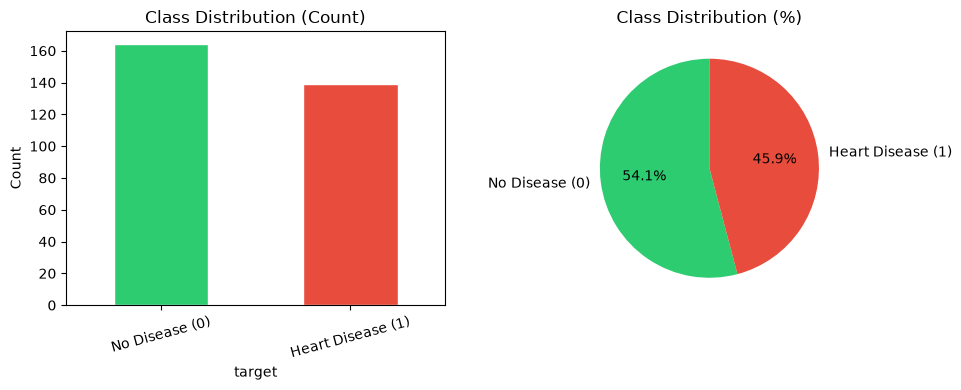

In [97]:
import matplotlib.pyplot as plt

counts = df_all[TARGET_COLUMN].value_counts().sort_index()
labels = {0: "No Disease (0)", 1: "Heart Disease (1)"}
print("Target distribution:")
for k, v in counts.items():
    print(f"  {labels[k]}: {v} ({v/len(df_all)*100:.1f}%)")
ratio = counts[0] / counts[1]
print(f"\nRatio No Disease : Disease = {ratio:.2f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts.plot(kind="bar", ax=axes[0], color=["#2ecc71", "#e74c3c"], edgecolor="white")
axes[0].set_title("Class Distribution (Count)")
axes[0].set_xticklabels([labels[k] for k in counts.index], rotation=15)
axes[0].set_ylabel("Count")
counts.plot(kind="pie", ax=axes[1], labels=[labels[k] for k in counts.index],
            colors=["#2ecc71", "#e74c3c"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class Distribution (%)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

---
## 3. DecisionTreeClassifier

In [98]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier

MODEL_NAME = "DecisionTreeClassifier"
TARGET_COLUMN = "target"
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
PARAM_GRID = [{'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1}, {'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 1}, {'max_depth': None, 'min_samples_split': 6, 'min_samples_leaf': 2}]


def parse_numeric_value(value):
    if pd.isna(value):
        return value
    if isinstance(value, str):
        cleaned = value.strip()
        if cleaned.count(".") > 1:
            sign = -1 if cleaned.startswith("-") else 1
            digits_only = cleaned[1:] if sign == -1 else cleaned
            digits_only = digits_only.replace(".", "")
            return sign * float(f"0.{digits_only}")
        return float(cleaned)
    return float(value)


def load_dataset(file_path):
    df = pd.read_csv(file_path)
    object_columns = df.select_dtypes(include="object").columns
    for col in object_columns:
        df[col] = df[col].map(parse_numeric_value)
    return df


def split_xy(df):
    x = df.drop(columns=[TARGET_COLUMN]).copy()
    y = df[TARGET_COLUMN].copy()
    return x, y


def build_preprocessor(feature_names):
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler()),
        ]
    )
    return ColumnTransformer(
        transformers=[("num", numeric_pipeline, feature_names)],
        remainder="drop",
    )


def build_model(params):
    estimator = clone(DecisionTreeClassifier(random_state=42)).set_params(**params)
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(feature_names)),
            ("model", estimator),
        ]
    )


def get_scores(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(x)
    return None


def evaluate_model(model, x, y):
    y_pred = model.predict(x)
    y_score = get_scores(model, x)
    metrics = {
        "accuracy": float(accuracy_score(y, y_pred)),
        "precision": float(precision_score(y, y_pred, zero_division=0)),
        "recall": float(recall_score(y, y_pred, zero_division=0)),
        "f1": float(f1_score(y, y_pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y, y_pred).tolist(),
    }
    if y_score is not None and len(np.unique(y)) > 1:
        metrics["roc_auc"] = float(roc_auc_score(y, y_score))
    return metrics


train_df = load_dataset(DATA_DIR / "train.csv")
val_df = load_dataset(DATA_DIR / "val.csv")
test_df = load_dataset(DATA_DIR / "test.csv")

x_train, y_train = split_xy(train_df)
x_val, y_val = split_xy(val_df)
x_test, y_test = split_xy(test_df)
feature_names = x_train.columns.tolist()

best_result = None

for params in PARAM_GRID:
    pipeline = build_model(params)
    pipeline.fit(x_train, y_train)
    train_metrics = evaluate_model(pipeline, x_train, y_train)
    val_metrics = evaluate_model(pipeline, x_val, y_val)
    current_result = {
        "params": params,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "model": pipeline,
    }
    if best_result is None:
        best_result = current_result
    else:
        current_key = (current_result["val_metrics"]["f1"], current_result["val_metrics"]["accuracy"])
        best_key = (best_result["val_metrics"]["f1"], best_result["val_metrics"]["accuracy"])
        if current_key > best_key:
            best_result = current_result

print("Best params on validation:", best_result["params"])
print("Train metrics:", json.dumps(best_result["train_metrics"], indent=2))
print("Validation metrics:", json.dumps(best_result["val_metrics"], indent=2))

x_train_val = pd.concat([x_train, x_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

final_model = build_model(best_result["params"])
final_model.fit(x_train_val, y_train_val)

train_val_metrics = evaluate_model(final_model, x_train_val, y_train_val)
test_metrics = evaluate_model(final_model, x_test, y_test)
test_predictions = final_model.predict(x_test)

models_dir = ARTIFACTS_DIR / "models"
reports_dir = ARTIFACTS_DIR / "reports"
predictions_dir = ARTIFACTS_DIR / "predictions"
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
predictions_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / f"{MODEL_NAME}.joblib"
report_path = reports_dir / f"{MODEL_NAME}_metrics.json"
prediction_path = predictions_dir / f"{MODEL_NAME}_test_predictions.csv"

joblib.dump(final_model, model_path)

prediction_df = x_test.copy()
prediction_df["actual_target"] = y_test.values
prediction_df["predicted_target"] = test_predictions
prediction_df.to_csv(prediction_path, index=False)

report = {
    "model_name": MODEL_NAME,
    "best_validation_params": best_result["params"],
    "train_metrics": best_result["train_metrics"],
    "validation_metrics": best_result["val_metrics"],
    "train_val_metrics_after_refit": train_val_metrics,
    "test_metrics": test_metrics,
    "saved_model_path": str(model_path),
    "prediction_path": str(prediction_path),
}

report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

print("\nTrain+Val metrics after refit:")
print(json.dumps(train_val_metrics, indent=2))
print("\nTest metrics:")
print(json.dumps(test_metrics, indent=2))
print("\nSaved model:", model_path)
print("Saved report:", report_path)
print("Saved predictions:", prediction_path)

prediction_df.head()


Best params on validation: {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1}
Train metrics: {
  "accuracy": 0.8429752066115702,
  "precision": 0.8686868686868687,
  "recall": 0.7747747747747747,
  "f1": 0.819047619047619,
  "confusion_matrix": [
    [
      118,
      13
    ],
    [
      25,
      86
    ]
  ],
  "roc_auc": 0.9073653806478236
}
Validation metrics: {
  "accuracy": 0.9333333333333333,
  "precision": 0.9285714285714286,
  "recall": 0.9285714285714286,
  "f1": 0.9285714285714286,
  "confusion_matrix": [
    [
      15,
      1
    ],
    [
      1,
      13
    ]
  ],
  "roc_auc": 0.9263392857142857
}

Train+Val metrics after refit:
{
  "accuracy": 0.8529411764705882,
  "precision": 0.8761061946902655,
  "recall": 0.792,
  "f1": 0.8319327731092437,
  "confusion_matrix": [
    [
      133,
      14
    ],
    [
      26,
      99
    ]
  ],
  "roc_auc": 0.9117278911564626
}

Test metrics:
{
  "accuracy": 0.8064516129032258,
  "precision": 0.7857142857142857,

/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/220332934.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include="object").columns
/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/220332934.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https:/

,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,actual_target,predicted_target
0,0.384303,-0.168240,-0.641646,-0.837597,0.107158,1.0,1.000000,0.0,1.0,1.0,0.5,1.0,1.0,1,1
1,-0.228879,-0.736870,-0.128635,0.106174,-0.891627,1.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0,0
2,0.829818,-0.545134,-0.357219,-0.175039,0.714629,1.0,0.666667,0.0,0.0,0.0,0.5,1.0,1.0,0,1
3,-0.395349,-0.545134,0.116827,-0.425278,-0.445445,0.0,0.666667,0.0,1.0,0.0,0.0,0.0,0.0,0,0
4,-0.139776,-0.623144,-0.186562,0.194515,-0.177735,1.0,0.666667,1.0,0.0,0.0,1.0,0.0,1.0,0,0


---
## 4. KNeighborsClassifier

In [99]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAME = "KNeighborsClassifier"
TARGET_COLUMN = "target"
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
PARAM_GRID = [
    {"n_neighbors": 4, "weights": "distance", "p": 2},
    {"n_neighbors": 5, "weights": "distance", "p": 2},
    {"n_neighbors": 7, "weights": "uniform", "p": 2},
]


def parse_numeric_value(value):
    if pd.isna(value):
        return value
    if isinstance(value, str):
        cleaned = value.strip()
        if cleaned.count(".") > 1:
            sign = -1 if cleaned.startswith("-") else 1
            digits_only = cleaned[1:] if sign == -1 else cleaned
            digits_only = digits_only.replace(".", "")
            return sign * float(f"0.{digits_only}")
        return float(cleaned)
    return float(value)


def load_dataset(file_path):
    df = pd.read_csv(file_path)
    object_columns = df.select_dtypes(include="object").columns
    for col in object_columns:
        df[col] = df[col].map(parse_numeric_value)
    return df


def split_xy(df):
    x = df.drop(columns=[TARGET_COLUMN]).copy()
    y = df[TARGET_COLUMN].copy()
    return x, y


def build_preprocessor(feature_names):
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    return ColumnTransformer(
        transformers=[("num", numeric_pipeline, feature_names)],
        remainder="drop",
    )


def build_model(params):
    estimator = clone(KNeighborsClassifier()).set_params(**params)
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(feature_names)),
            ("model", estimator),
        ]
    )


def get_scores(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(x)
    return None


def evaluate_model(model, x, y):
    y_pred = model.predict(x)
    y_score = get_scores(model, x)
    metrics = {
        "accuracy": float(accuracy_score(y, y_pred)),
        "precision": float(precision_score(y, y_pred, zero_division=0)),
        "recall": float(recall_score(y, y_pred, zero_division=0)),
        "f1": float(f1_score(y, y_pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y, y_pred).tolist(),
    }
    if y_score is not None and len(np.unique(y)) > 1:
        metrics["roc_auc"] = float(roc_auc_score(y, y_score))
    return metrics


train_df = load_dataset(DATA_DIR / "train.csv")
val_df = load_dataset(DATA_DIR / "val.csv")
test_df = load_dataset(DATA_DIR / "test.csv")

x_train, y_train = split_xy(train_df)
x_val, y_val = split_xy(val_df)
x_test, y_test = split_xy(test_df)
feature_names = x_train.columns.tolist()

best_result = None

for params in PARAM_GRID:
    pipeline = build_model(params)
    pipeline.fit(x_train, y_train)
    train_metrics = evaluate_model(pipeline, x_train, y_train)
    val_metrics = evaluate_model(pipeline, x_val, y_val)
    current_result = {
        "params": params,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "model": pipeline,
    }
    if best_result is None:
        best_result = current_result
    else:
        current_key = (current_result["val_metrics"]["f1"], current_result["val_metrics"]["accuracy"])
        best_key = (best_result["val_metrics"]["f1"], best_result["val_metrics"]["accuracy"])
        if current_key > best_key:
            best_result = current_result

print("Best params on validation:", best_result["params"])
print("Train metrics:", json.dumps(best_result["train_metrics"], indent=2))
print("Validation metrics:", json.dumps(best_result["val_metrics"], indent=2))

x_train_val = pd.concat([x_train, x_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

final_model = build_model(best_result["params"])
final_model.fit(x_train_val, y_train_val)

train_val_metrics = evaluate_model(final_model, x_train_val, y_train_val)
test_metrics = evaluate_model(final_model, x_test, y_test)
test_predictions = final_model.predict(x_test)

models_dir = ARTIFACTS_DIR / "models"
reports_dir = ARTIFACTS_DIR / "reports"
predictions_dir = ARTIFACTS_DIR / "predictions"
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
predictions_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / f"{MODEL_NAME}.joblib"
report_path = reports_dir / f"{MODEL_NAME}_metrics.json"
prediction_path = predictions_dir / f"{MODEL_NAME}_test_predictions.csv"

joblib.dump(final_model, model_path)

prediction_df = x_test.copy()
prediction_df["actual_target"] = y_test.values
prediction_df["predicted_target"] = test_predictions
prediction_df.to_csv(prediction_path, index=False)

report = {
    "model_name": MODEL_NAME,
    "best_validation_params": best_result["params"],
    "train_metrics": best_result["train_metrics"],
    "validation_metrics": best_result["val_metrics"],
    "train_val_metrics_after_refit": train_val_metrics,
    "test_metrics": test_metrics,
    "saved_model_path": str(model_path),
    "prediction_path": str(prediction_path),
}

report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

print("\nTrain+Val metrics after refit:")
print(json.dumps(train_val_metrics, indent=2))
print("\nTest metrics:")
print(json.dumps(test_metrics, indent=2))
print("\nSaved model:", model_path)
print("Saved report:", report_path)
print("Saved predictions:", prediction_path)

prediction_df.head()


/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/563382473.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include="object").columns
/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/563382473.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https:/

Best params on validation: {'n_neighbors': 4, 'weights': 'distance', 'p': 2}
Train metrics: {
  "accuracy": 1.0,
  "precision": 1.0,
  "recall": 1.0,
  "f1": 1.0,
  "confusion_matrix": [
    [
      131,
      0
    ],
    [
      0,
      111
    ]
  ],
  "roc_auc": 1.0
}
Validation metrics: {
  "accuracy": 0.8333333333333334,
  "precision": 0.7647058823529411,
  "recall": 0.9285714285714286,
  "f1": 0.8387096774193549,
  "confusion_matrix": [
    [
      12,
      4
    ],
    [
      1,
      13
    ]
  ],
  "roc_auc": 0.8705357142857142
}

Train+Val metrics after refit:
{
  "accuracy": 1.0,
  "precision": 1.0,
  "recall": 1.0,
  "f1": 1.0,
  "confusion_matrix": [
    [
      147,
      0
    ],
    [
      0,
      125
    ]
  ],
  "roc_auc": 1.0
}

Test metrics:
{
  "accuracy": 0.8064516129032258,
  "precision": 0.7222222222222222,
  "recall": 0.9285714285714286,
  "f1": 0.8125,
  "confusion_matrix": [
    [
      12,
      5
    ],
    [
      1,
      13
    ]
  ],
  "roc_auc": 

,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,actual_target,predicted_target
0,0.384303,-0.168240,-0.641646,-0.837597,0.107158,1.0,1.000000,0.0,1.0,1.0,0.5,1.0,1.0,1,1
1,-0.228879,-0.736870,-0.128635,0.106174,-0.891627,1.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0,0
2,0.829818,-0.545134,-0.357219,-0.175039,0.714629,1.0,0.666667,0.0,0.0,0.0,0.5,1.0,1.0,0,1
3,-0.395349,-0.545134,0.116827,-0.425278,-0.445445,0.0,0.666667,0.0,1.0,0.0,0.0,0.0,0.0,0,0
4,-0.139776,-0.623144,-0.186562,0.194515,-0.177735,1.0,0.666667,1.0,0.0,0.0,1.0,0.0,1.0,0,0


---
## 5. GaussianNB

In [100]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAME = "GaussianNB"
TARGET_COLUMN = "target"
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
PARAM_GRID = [
    {"var_smoothing": 1e-12},
    {"var_smoothing": 1e-10},
    {"var_smoothing": 1e-8},
]


def parse_numeric_value(value):
    if pd.isna(value):
        return value
    if isinstance(value, str):
        cleaned = value.strip()
        if cleaned.count(".") > 1:
            sign = -1 if cleaned.startswith("-") else 1
            digits_only = cleaned[1:] if sign == -1 else cleaned
            digits_only = digits_only.replace(".", "")
            return sign * float(f"0.{digits_only}")
        return float(cleaned)
    return float(value)


def load_dataset(file_path):
    df = pd.read_csv(file_path)
    object_columns = df.select_dtypes(include="object").columns
    for col in object_columns:
        df[col] = df[col].map(parse_numeric_value)
    return df


def split_xy(df):
    x = df.drop(columns=[TARGET_COLUMN]).copy()
    y = df[TARGET_COLUMN].copy()
    return x, y


def build_preprocessor(feature_names):
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    return ColumnTransformer(
        transformers=[("num", numeric_pipeline, feature_names)],
        remainder="drop",
    )


def build_model(params):
    estimator = clone(GaussianNB()).set_params(**params)
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(feature_names)),
            ("model", estimator),
        ]
    )


def get_scores(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(x)
    return None


def evaluate_model(model, x, y):
    y_pred = model.predict(x)
    y_score = get_scores(model, x)
    metrics = {
        "accuracy": float(accuracy_score(y, y_pred)),
        "precision": float(precision_score(y, y_pred, zero_division=0)),
        "recall": float(recall_score(y, y_pred, zero_division=0)),
        "f1": float(f1_score(y, y_pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y, y_pred).tolist(),
    }
    if y_score is not None and len(np.unique(y)) > 1:
        metrics["roc_auc"] = float(roc_auc_score(y, y_score))
    return metrics


train_df = load_dataset(DATA_DIR / "train.csv")
val_df = load_dataset(DATA_DIR / "val.csv")
test_df = load_dataset(DATA_DIR / "test.csv")

x_train, y_train = split_xy(train_df)
x_val, y_val = split_xy(val_df)
x_test, y_test = split_xy(test_df)
feature_names = x_train.columns.tolist()

best_result = None

for params in PARAM_GRID:
    pipeline = build_model(params)
    pipeline.fit(x_train, y_train)
    train_metrics = evaluate_model(pipeline, x_train, y_train)
    val_metrics = evaluate_model(pipeline, x_val, y_val)
    current_result = {
        "params": params,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "model": pipeline,
    }
    if best_result is None:
        best_result = current_result
    else:
        current_key = (current_result["val_metrics"]["f1"], current_result["val_metrics"]["accuracy"])
        best_key = (best_result["val_metrics"]["f1"], best_result["val_metrics"]["accuracy"])
        if current_key > best_key:
            best_result = current_result

print("Best params on validation:", best_result["params"])
print("Train metrics:", json.dumps(best_result["train_metrics"], indent=2))
print("Validation metrics:", json.dumps(best_result["val_metrics"], indent=2))

x_train_val = pd.concat([x_train, x_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

final_model = build_model(best_result["params"])
final_model.fit(x_train_val, y_train_val)

train_val_metrics = evaluate_model(final_model, x_train_val, y_train_val)
test_metrics = evaluate_model(final_model, x_test, y_test)
test_predictions = final_model.predict(x_test)

models_dir = ARTIFACTS_DIR / "models"
reports_dir = ARTIFACTS_DIR / "reports"
predictions_dir = ARTIFACTS_DIR / "predictions"
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
predictions_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / f"{MODEL_NAME}.joblib"
report_path = reports_dir / f"{MODEL_NAME}_metrics.json"
prediction_path = predictions_dir / f"{MODEL_NAME}_test_predictions.csv"

joblib.dump(final_model, model_path)

prediction_df = x_test.copy()
prediction_df["actual_target"] = y_test.values
prediction_df["predicted_target"] = test_predictions
prediction_df.to_csv(prediction_path, index=False)

report = {
    "model_name": MODEL_NAME,
    "best_validation_params": best_result["params"],
    "train_metrics": best_result["train_metrics"],
    "validation_metrics": best_result["val_metrics"],
    "train_val_metrics_after_refit": train_val_metrics,
    "test_metrics": test_metrics,
    "saved_model_path": str(model_path),
    "prediction_path": str(prediction_path),
}

report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

print("\nTrain+Val metrics after refit:")
print(json.dumps(train_val_metrics, indent=2))
print("\nTest metrics:")
print(json.dumps(test_metrics, indent=2))
print("\nSaved model:", model_path)
print("Saved report:", report_path)
print("Saved predictions:", prediction_path)

prediction_df.head()


/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/3240029230.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include="object").columns
/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/3240029230.py:42: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https

Best params on validation: {'var_smoothing': 1e-12}
Train metrics: {
  "accuracy": 0.8305785123966942,
  "precision": 0.8301886792452831,
  "recall": 0.7927927927927928,
  "f1": 0.8110599078341014,
  "confusion_matrix": [
    [
      113,
      18
    ],
    [
      23,
      88
    ]
  ],
  "roc_auc": 0.9050271645691493
}
Validation metrics: {
  "accuracy": 0.9666666666666667,
  "precision": 0.9333333333333333,
  "recall": 1.0,
  "f1": 0.9655172413793104,
  "confusion_matrix": [
    [
      15,
      1
    ],
    [
      0,
      14
    ]
  ],
  "roc_auc": 0.9955357142857143
}

Train+Val metrics after refit:
{
  "accuracy": 0.8455882352941176,
  "precision": 0.8429752066115702,
  "recall": 0.816,
  "f1": 0.8292682926829268,
  "confusion_matrix": [
    [
      128,
      19
    ],
    [
      23,
      102
    ]
  ],
  "roc_auc": 0.9139591836734694
}

Test metrics:
{
  "accuracy": 0.7741935483870968,
  "precision": 0.7058823529411765,
  "recall": 0.8571428571428571,
  "f1": 0.774193548

,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,actual_target,predicted_target
0,0.384303,-0.168240,-0.641646,-0.837597,0.107158,1.0,1.000000,0.0,1.0,1.0,0.5,1.0,1.0,1,1
1,-0.228879,-0.736870,-0.128635,0.106174,-0.891627,1.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0,0
2,0.829818,-0.545134,-0.357219,-0.175039,0.714629,1.0,0.666667,0.0,0.0,0.0,0.5,1.0,1.0,0,1
3,-0.395349,-0.545134,0.116827,-0.425278,-0.445445,0.0,0.666667,0.0,1.0,0.0,0.0,0.0,0.0,0,0
4,-0.139776,-0.623144,-0.186562,0.194515,-0.177735,1.0,0.666667,1.0,0.0,0.0,1.0,0.0,1.0,0,1


---
## 6. RandomForestClassifier

In [101]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

MODEL_NAME = "RandomForestClassifier"
TARGET_COLUMN = "target"
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
PARAM_GRID = [{'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 2}, {'n_estimators': 200, 'max_depth': 8, 'min_samples_split': 2}, {'n_estimators': 250, 'max_depth': None, 'min_samples_split': 4}]


def parse_numeric_value(value):
    if pd.isna(value):
        return value
    if isinstance(value, str):
        cleaned = value.strip()
        if cleaned.count(".") > 1:
            sign = -1 if cleaned.startswith("-") else 1
            digits_only = cleaned[1:] if sign == -1 else cleaned
            digits_only = digits_only.replace(".", "")
            return sign * float(f"0.{digits_only}")
        return float(cleaned)
    return float(value)


def load_dataset(file_path):
    df = pd.read_csv(file_path)
    object_columns = df.select_dtypes(include="object").columns
    for col in object_columns:
        df[col] = df[col].map(parse_numeric_value)
    return df


def split_xy(df):
    x = df.drop(columns=[TARGET_COLUMN]).copy()
    y = df[TARGET_COLUMN].copy()
    return x, y


def build_preprocessor(feature_names):
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler()),
        ]
    )
    return ColumnTransformer(
        transformers=[("num", numeric_pipeline, feature_names)],
        remainder="drop",
    )


def build_model(params):
    estimator = clone(RandomForestClassifier(random_state=42, n_jobs=-1)).set_params(**params)
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(feature_names)),
            ("model", estimator),
        ]
    )


def get_scores(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(x)
    return None


def evaluate_model(model, x, y):
    y_pred = model.predict(x)
    y_score = get_scores(model, x)
    metrics = {
        "accuracy": float(accuracy_score(y, y_pred)),
        "precision": float(precision_score(y, y_pred, zero_division=0)),
        "recall": float(recall_score(y, y_pred, zero_division=0)),
        "f1": float(f1_score(y, y_pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y, y_pred).tolist(),
    }
    if y_score is not None and len(np.unique(y)) > 1:
        metrics["roc_auc"] = float(roc_auc_score(y, y_score))
    return metrics


train_df = load_dataset(DATA_DIR / "train.csv")
val_df = load_dataset(DATA_DIR / "val.csv")
test_df = load_dataset(DATA_DIR / "test.csv")

x_train, y_train = split_xy(train_df)
x_val, y_val = split_xy(val_df)
x_test, y_test = split_xy(test_df)
feature_names = x_train.columns.tolist()

best_result = None

for params in PARAM_GRID:
    pipeline = build_model(params)
    pipeline.fit(x_train, y_train)
    train_metrics = evaluate_model(pipeline, x_train, y_train)
    val_metrics = evaluate_model(pipeline, x_val, y_val)
    current_result = {
        "params": params,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "model": pipeline,
    }
    if best_result is None:
        best_result = current_result
    else:
        current_key = (current_result["val_metrics"]["f1"], current_result["val_metrics"]["accuracy"])
        best_key = (best_result["val_metrics"]["f1"], best_result["val_metrics"]["accuracy"])
        if current_key > best_key:
            best_result = current_result

print("Best params on validation:", best_result["params"])
print("Train metrics:", json.dumps(best_result["train_metrics"], indent=2))
print("Validation metrics:", json.dumps(best_result["val_metrics"], indent=2))

x_train_val = pd.concat([x_train, x_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

final_model = build_model(best_result["params"])
final_model.fit(x_train_val, y_train_val)

train_val_metrics = evaluate_model(final_model, x_train_val, y_train_val)
test_metrics = evaluate_model(final_model, x_test, y_test)
test_predictions = final_model.predict(x_test)

models_dir = ARTIFACTS_DIR / "models"
reports_dir = ARTIFACTS_DIR / "reports"
predictions_dir = ARTIFACTS_DIR / "predictions"
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
predictions_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / f"{MODEL_NAME}.joblib"
report_path = reports_dir / f"{MODEL_NAME}_metrics.json"
prediction_path = predictions_dir / f"{MODEL_NAME}_test_predictions.csv"

joblib.dump(final_model, model_path)

prediction_df = x_test.copy()
prediction_df["actual_target"] = y_test.values
prediction_df["predicted_target"] = test_predictions
prediction_df.to_csv(prediction_path, index=False)

report = {
    "model_name": MODEL_NAME,
    "best_validation_params": best_result["params"],
    "train_metrics": best_result["train_metrics"],
    "validation_metrics": best_result["val_metrics"],
    "train_val_metrics_after_refit": train_val_metrics,
    "test_metrics": test_metrics,
    "saved_model_path": str(model_path),
    "prediction_path": str(prediction_path),
}

report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

print("\nTrain+Val metrics after refit:")
print(json.dumps(train_val_metrics, indent=2))
print("\nTest metrics:")
print(json.dumps(test_metrics, indent=2))
print("\nSaved model:", model_path)
print("Saved report:", report_path)
print("Saved predictions:", prediction_path)

prediction_df.head()


/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/2796681175.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include="object").columns
/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/2796681175.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https

Best params on validation: {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 2}
Train metrics: {
  "accuracy": 0.9338842975206612,
  "precision": 0.9702970297029703,
  "recall": 0.8828828828828829,
  "f1": 0.9245283018867925,
  "confusion_matrix": [
    [
      128,
      3
    ],
    [
      13,
      98
    ]
  ],
  "roc_auc": 0.9871398115672925
}
Validation metrics: {
  "accuracy": 0.9333333333333333,
  "precision": 0.875,
  "recall": 1.0,
  "f1": 0.9333333333333333,
  "confusion_matrix": [
    [
      14,
      2
    ],
    [
      0,
      14
    ]
  ],
  "roc_auc": 0.9955357142857143
}

Train+Val metrics after refit:
{
  "accuracy": 0.9338235294117647,
  "precision": 0.9652173913043478,
  "recall": 0.888,
  "f1": 0.925,
  "confusion_matrix": [
    [
      143,
      4
    ],
    [
      14,
      111
    ]
  ],
  "roc_auc": 0.9866666666666667
}

Test metrics:
{
  "accuracy": 0.8709677419354839,
  "precision": 0.8571428571428571,
  "recall": 0.8571428571428571,
  "f1": 0.

,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,actual_target,predicted_target
0,0.384303,-0.168240,-0.641646,-0.837597,0.107158,1.0,1.000000,0.0,1.0,1.0,0.5,1.0,1.0,1,1
1,-0.228879,-0.736870,-0.128635,0.106174,-0.891627,1.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0,0
2,0.829818,-0.545134,-0.357219,-0.175039,0.714629,1.0,0.666667,0.0,0.0,0.0,0.5,1.0,1.0,0,1
3,-0.395349,-0.545134,0.116827,-0.425278,-0.445445,0.0,0.666667,0.0,1.0,0.0,0.0,0.0,0.0,0,0
4,-0.139776,-0.623144,-0.186562,0.194515,-0.177735,1.0,0.666667,1.0,0.0,0.0,1.0,0.0,1.0,0,0


---
## 7. AdaBoostClassifier

In [102]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import AdaBoostClassifier

MODEL_NAME = "AdaBoostClassifier"
TARGET_COLUMN = "target"
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
PARAM_GRID = [{'n_estimators': 50, 'learning_rate': 0.5}, {'n_estimators': 100, 'learning_rate': 0.5}, {'n_estimators': 150, 'learning_rate': 0.1}]


def parse_numeric_value(value):
    if pd.isna(value):
        return value
    if isinstance(value, str):
        cleaned = value.strip()
        if cleaned.count(".") > 1:
            sign = -1 if cleaned.startswith("-") else 1
            digits_only = cleaned[1:] if sign == -1 else cleaned
            digits_only = digits_only.replace(".", "")
            return sign * float(f"0.{digits_only}")
        return float(cleaned)
    return float(value)


def load_dataset(file_path):
    df = pd.read_csv(file_path)
    object_columns = df.select_dtypes(include="object").columns
    for col in object_columns:
        df[col] = df[col].map(parse_numeric_value)
    return df


def split_xy(df):
    x = df.drop(columns=[TARGET_COLUMN]).copy()
    y = df[TARGET_COLUMN].copy()
    return x, y


def build_preprocessor(feature_names):
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler()),
        ]
    )
    return ColumnTransformer(
        transformers=[("num", numeric_pipeline, feature_names)],
        remainder="drop",
    )


def build_model(params):
    estimator = clone(AdaBoostClassifier(random_state=42)).set_params(**params)
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(feature_names)),
            ("model", estimator),
        ]
    )


def get_scores(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(x)
    return None


def evaluate_model(model, x, y):
    y_pred = model.predict(x)
    y_score = get_scores(model, x)
    metrics = {
        "accuracy": float(accuracy_score(y, y_pred)),
        "precision": float(precision_score(y, y_pred, zero_division=0)),
        "recall": float(recall_score(y, y_pred, zero_division=0)),
        "f1": float(f1_score(y, y_pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y, y_pred).tolist(),
    }
    if y_score is not None and len(np.unique(y)) > 1:
        metrics["roc_auc"] = float(roc_auc_score(y, y_score))
    return metrics


train_df = load_dataset(DATA_DIR / "train.csv")
val_df = load_dataset(DATA_DIR / "val.csv")
test_df = load_dataset(DATA_DIR / "test.csv")

x_train, y_train = split_xy(train_df)
x_val, y_val = split_xy(val_df)
x_test, y_test = split_xy(test_df)
feature_names = x_train.columns.tolist()

best_result = None

for params in PARAM_GRID:
    pipeline = build_model(params)
    pipeline.fit(x_train, y_train)
    train_metrics = evaluate_model(pipeline, x_train, y_train)
    val_metrics = evaluate_model(pipeline, x_val, y_val)
    current_result = {
        "params": params,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "model": pipeline,
    }
    if best_result is None:
        best_result = current_result
    else:
        current_key = (current_result["val_metrics"]["f1"], current_result["val_metrics"]["accuracy"])
        best_key = (best_result["val_metrics"]["f1"], best_result["val_metrics"]["accuracy"])
        if current_key > best_key:
            best_result = current_result

print("Best params on validation:", best_result["params"])
print("Train metrics:", json.dumps(best_result["train_metrics"], indent=2))
print("Validation metrics:", json.dumps(best_result["val_metrics"], indent=2))

x_train_val = pd.concat([x_train, x_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

final_model = build_model(best_result["params"])
final_model.fit(x_train_val, y_train_val)

train_val_metrics = evaluate_model(final_model, x_train_val, y_train_val)
test_metrics = evaluate_model(final_model, x_test, y_test)
test_predictions = final_model.predict(x_test)

models_dir = ARTIFACTS_DIR / "models"
reports_dir = ARTIFACTS_DIR / "reports"
predictions_dir = ARTIFACTS_DIR / "predictions"
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
predictions_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / f"{MODEL_NAME}.joblib"
report_path = reports_dir / f"{MODEL_NAME}_metrics.json"
prediction_path = predictions_dir / f"{MODEL_NAME}_test_predictions.csv"

joblib.dump(final_model, model_path)

prediction_df = x_test.copy()
prediction_df["actual_target"] = y_test.values
prediction_df["predicted_target"] = test_predictions
prediction_df.to_csv(prediction_path, index=False)

report = {
    "model_name": MODEL_NAME,
    "best_validation_params": best_result["params"],
    "train_metrics": best_result["train_metrics"],
    "validation_metrics": best_result["val_metrics"],
    "train_val_metrics_after_refit": train_val_metrics,
    "test_metrics": test_metrics,
    "saved_model_path": str(model_path),
    "prediction_path": str(prediction_path),
}

report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

print("\nTrain+Val metrics after refit:")
print(json.dumps(train_val_metrics, indent=2))
print("\nTest metrics:")
print(json.dumps(test_metrics, indent=2))
print("\nSaved model:", model_path)
print("Saved report:", report_path)
print("Saved predictions:", prediction_path)

prediction_df.head()


/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/2451922723.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include="object").columns
/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/2451922723.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https

Best params on validation: {'n_estimators': 150, 'learning_rate': 0.1}
Train metrics: {
  "accuracy": 0.8636363636363636,
  "precision": 0.875,
  "recall": 0.8198198198198198,
  "f1": 0.8465116279069768,
  "confusion_matrix": [
    [
      118,
      13
    ],
    [
      20,
      91
    ]
  ],
  "roc_auc": 0.9393095385461797
}
Validation metrics: {
  "accuracy": 0.9666666666666667,
  "precision": 0.9333333333333333,
  "recall": 1.0,
  "f1": 0.9655172413793104,
  "confusion_matrix": [
    [
      15,
      1
    ],
    [
      0,
      14
    ]
  ],
  "roc_auc": 0.9732142857142857
}

Train+Val metrics after refit:
{
  "accuracy": 0.8786764705882353,
  "precision": 0.8833333333333333,
  "recall": 0.848,
  "f1": 0.8653061224489796,
  "confusion_matrix": [
    [
      133,
      14
    ],
    [
      19,
      106
    ]
  ],
  "roc_auc": 0.940625850340136
}

Test metrics:
{
  "accuracy": 0.8064516129032258,
  "precision": 0.7857142857142857,
  "recall": 0.7857142857142857,
  "f1": 0.7857

,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,actual_target,predicted_target
0,0.384303,-0.168240,-0.641646,-0.837597,0.107158,1.0,1.000000,0.0,1.0,1.0,0.5,1.0,1.0,1,1
1,-0.228879,-0.736870,-0.128635,0.106174,-0.891627,1.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0,0
2,0.829818,-0.545134,-0.357219,-0.175039,0.714629,1.0,0.666667,0.0,0.0,0.0,0.5,1.0,1.0,0,1
3,-0.395349,-0.545134,0.116827,-0.425278,-0.445445,0.0,0.666667,0.0,1.0,0.0,0.0,0.0,0.0,0,0
4,-0.139776,-0.623144,-0.186562,0.194515,-0.177735,1.0,0.666667,1.0,0.0,0.0,1.0,0.0,1.0,0,0


---
## 8. GradientBoostingClassifier

In [103]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier

MODEL_NAME = "GradientBoostingClassifier"
TARGET_COLUMN = "target"
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
PARAM_GRID = [{'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2}, {'n_estimators': 150, 'learning_rate': 0.1, 'max_depth': 2}, {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3}]


def parse_numeric_value(value):
    if pd.isna(value):
        return value
    if isinstance(value, str):
        cleaned = value.strip()
        if cleaned.count(".") > 1:
            sign = -1 if cleaned.startswith("-") else 1
            digits_only = cleaned[1:] if sign == -1 else cleaned
            digits_only = digits_only.replace(".", "")
            return sign * float(f"0.{digits_only}")
        return float(cleaned)
    return float(value)


def load_dataset(file_path):
    df = pd.read_csv(file_path)
    object_columns = df.select_dtypes(include="object").columns
    for col in object_columns:
        df[col] = df[col].map(parse_numeric_value)
    return df


def split_xy(df):
    x = df.drop(columns=[TARGET_COLUMN]).copy()
    y = df[TARGET_COLUMN].copy()
    return x, y


def build_preprocessor(feature_names):
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler()),
        ]
    )
    return ColumnTransformer(
        transformers=[("num", numeric_pipeline, feature_names)],
        remainder="drop",
    )


def build_model(params):
    estimator = clone(GradientBoostingClassifier(random_state=42)).set_params(**params)
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(feature_names)),
            ("model", estimator),
        ]
    )


def get_scores(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(x)
    return None


def evaluate_model(model, x, y):
    y_pred = model.predict(x)
    y_score = get_scores(model, x)
    metrics = {
        "accuracy": float(accuracy_score(y, y_pred)),
        "precision": float(precision_score(y, y_pred, zero_division=0)),
        "recall": float(recall_score(y, y_pred, zero_division=0)),
        "f1": float(f1_score(y, y_pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y, y_pred).tolist(),
    }
    if y_score is not None and len(np.unique(y)) > 1:
        metrics["roc_auc"] = float(roc_auc_score(y, y_score))
    return metrics


train_df = load_dataset(DATA_DIR / "train.csv")
val_df = load_dataset(DATA_DIR / "val.csv")
test_df = load_dataset(DATA_DIR / "test.csv")

x_train, y_train = split_xy(train_df)
x_val, y_val = split_xy(val_df)
x_test, y_test = split_xy(test_df)
feature_names = x_train.columns.tolist()

best_result = None

for params in PARAM_GRID:
    pipeline = build_model(params)
    pipeline.fit(x_train, y_train)
    train_metrics = evaluate_model(pipeline, x_train, y_train)
    val_metrics = evaluate_model(pipeline, x_val, y_val)
    current_result = {
        "params": params,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "model": pipeline,
    }
    if best_result is None:
        best_result = current_result
    else:
        current_key = (current_result["val_metrics"]["f1"], current_result["val_metrics"]["accuracy"])
        best_key = (best_result["val_metrics"]["f1"], best_result["val_metrics"]["accuracy"])
        if current_key > best_key:
            best_result = current_result

print("Best params on validation:", best_result["params"])
print("Train metrics:", json.dumps(best_result["train_metrics"], indent=2))
print("Validation metrics:", json.dumps(best_result["val_metrics"], indent=2))

x_train_val = pd.concat([x_train, x_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

final_model = build_model(best_result["params"])
final_model.fit(x_train_val, y_train_val)

train_val_metrics = evaluate_model(final_model, x_train_val, y_train_val)
test_metrics = evaluate_model(final_model, x_test, y_test)
test_predictions = final_model.predict(x_test)

models_dir = ARTIFACTS_DIR / "models"
reports_dir = ARTIFACTS_DIR / "reports"
predictions_dir = ARTIFACTS_DIR / "predictions"
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
predictions_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / f"{MODEL_NAME}.joblib"
report_path = reports_dir / f"{MODEL_NAME}_metrics.json"
prediction_path = predictions_dir / f"{MODEL_NAME}_test_predictions.csv"

joblib.dump(final_model, model_path)

prediction_df = x_test.copy()
prediction_df["actual_target"] = y_test.values
prediction_df["predicted_target"] = test_predictions
prediction_df.to_csv(prediction_path, index=False)

report = {
    "model_name": MODEL_NAME,
    "best_validation_params": best_result["params"],
    "train_metrics": best_result["train_metrics"],
    "validation_metrics": best_result["val_metrics"],
    "train_val_metrics_after_refit": train_val_metrics,
    "test_metrics": test_metrics,
    "saved_model_path": str(model_path),
    "prediction_path": str(prediction_path),
}

report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

print("\nTrain+Val metrics after refit:")
print(json.dumps(train_val_metrics, indent=2))
print("\nTest metrics:")
print(json.dumps(test_metrics, indent=2))
print("\nSaved model:", model_path)
print("Saved report:", report_path)
print("Saved predictions:", prediction_path)

prediction_df.head()


/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/4043098879.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include="object").columns
/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/4043098879.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https

Best params on validation: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2}
Train metrics: {
  "accuracy": 0.9132231404958677,
  "precision": 0.9245283018867925,
  "recall": 0.8828828828828829,
  "f1": 0.9032258064516129,
  "confusion_matrix": [
    [
      123,
      8
    ],
    [
      13,
      98
    ]
  ],
  "roc_auc": 0.9656832404924008
}
Validation metrics: {
  "accuracy": 0.9,
  "precision": 0.8235294117647058,
  "recall": 1.0,
  "f1": 0.9032258064516129,
  "confusion_matrix": [
    [
      13,
      3
    ],
    [
      0,
      14
    ]
  ],
  "roc_auc": 0.9776785714285714
}

Train+Val metrics after refit:
{
  "accuracy": 0.9044117647058824,
  "precision": 0.9159663865546218,
  "recall": 0.872,
  "f1": 0.8934426229508197,
  "confusion_matrix": [
    [
      137,
      10
    ],
    [
      16,
      109
    ]
  ],
  "roc_auc": 0.9635374149659864
}

Test metrics:
{
  "accuracy": 0.8387096774193549,
  "precision": 0.8,
  "recall": 0.8571428571428571,
  "f1": 0.8275

,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,actual_target,predicted_target
0,0.384303,-0.168240,-0.641646,-0.837597,0.107158,1.0,1.000000,0.0,1.0,1.0,0.5,1.0,1.0,1,1
1,-0.228879,-0.736870,-0.128635,0.106174,-0.891627,1.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0,0
2,0.829818,-0.545134,-0.357219,-0.175039,0.714629,1.0,0.666667,0.0,0.0,0.0,0.5,1.0,1.0,0,1
3,-0.395349,-0.545134,0.116827,-0.425278,-0.445445,0.0,0.666667,0.0,1.0,0.0,0.0,0.0,0.0,0,0
4,-0.139776,-0.623144,-0.186562,0.194515,-0.177735,1.0,0.666667,1.0,0.0,0.0,1.0,0.0,1.0,0,0


---
## 9. XGBClassifier

In [104]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier

MODEL_NAME = "XGBClassifier"
TARGET_COLUMN = "target"
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
PARAM_GRID = [{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}, {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.05}, {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}]


def parse_numeric_value(value):
    if pd.isna(value):
        return value
    if isinstance(value, str):
        cleaned = value.strip()
        if cleaned.count(".") > 1:
            sign = -1 if cleaned.startswith("-") else 1
            digits_only = cleaned[1:] if sign == -1 else cleaned
            digits_only = digits_only.replace(".", "")
            return sign * float(f"0.{digits_only}")
        return float(cleaned)
    return float(value)


def load_dataset(file_path):
    df = pd.read_csv(file_path)
    object_columns = df.select_dtypes(include="object").columns
    for col in object_columns:
        df[col] = df[col].map(parse_numeric_value)
    return df


def split_xy(df):
    x = df.drop(columns=[TARGET_COLUMN]).copy()
    y = df[TARGET_COLUMN].copy()
    return x, y


def build_preprocessor(feature_names):
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler()),
        ]
    )
    return ColumnTransformer(
        transformers=[("num", numeric_pipeline, feature_names)],
        remainder="drop",
    )


def build_model(params):
    estimator = clone(XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=1)).set_params(**params)
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(feature_names)),
            ("model", estimator),
        ]
    )


def get_scores(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(x)
    return None


def evaluate_model(model, x, y):
    y_pred = model.predict(x)
    y_score = get_scores(model, x)
    metrics = {
        "accuracy": float(accuracy_score(y, y_pred)),
        "precision": float(precision_score(y, y_pred, zero_division=0)),
        "recall": float(recall_score(y, y_pred, zero_division=0)),
        "f1": float(f1_score(y, y_pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y, y_pred).tolist(),
    }
    if y_score is not None and len(np.unique(y)) > 1:
        metrics["roc_auc"] = float(roc_auc_score(y, y_score))
    return metrics


train_df = load_dataset(DATA_DIR / "train.csv")
val_df = load_dataset(DATA_DIR / "val.csv")
test_df = load_dataset(DATA_DIR / "test.csv")

x_train, y_train = split_xy(train_df)
x_val, y_val = split_xy(val_df)
x_test, y_test = split_xy(test_df)
feature_names = x_train.columns.tolist()

best_result = None

for params in PARAM_GRID:
    pipeline = build_model(params)
    pipeline.fit(x_train, y_train)
    train_metrics = evaluate_model(pipeline, x_train, y_train)
    val_metrics = evaluate_model(pipeline, x_val, y_val)
    current_result = {
        "params": params,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "model": pipeline,
    }
    if best_result is None:
        best_result = current_result
    else:
        current_key = (current_result["val_metrics"]["f1"], current_result["val_metrics"]["accuracy"])
        best_key = (best_result["val_metrics"]["f1"], best_result["val_metrics"]["accuracy"])
        if current_key > best_key:
            best_result = current_result

print("Best params on validation:", best_result["params"])
print("Train metrics:", json.dumps(best_result["train_metrics"], indent=2))
print("Validation metrics:", json.dumps(best_result["val_metrics"], indent=2))

x_train_val = pd.concat([x_train, x_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

final_model = build_model(best_result["params"])
final_model.fit(x_train_val, y_train_val)

train_val_metrics = evaluate_model(final_model, x_train_val, y_train_val)
test_metrics = evaluate_model(final_model, x_test, y_test)
test_predictions = final_model.predict(x_test)

models_dir = ARTIFACTS_DIR / "models"
reports_dir = ARTIFACTS_DIR / "reports"
predictions_dir = ARTIFACTS_DIR / "predictions"
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
predictions_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / f"{MODEL_NAME}.joblib"
report_path = reports_dir / f"{MODEL_NAME}_metrics.json"
prediction_path = predictions_dir / f"{MODEL_NAME}_test_predictions.csv"

joblib.dump(final_model, model_path)

prediction_df = x_test.copy()
prediction_df["actual_target"] = y_test.values
prediction_df["predicted_target"] = test_predictions
prediction_df.to_csv(prediction_path, index=False)

report = {
    "model_name": MODEL_NAME,
    "best_validation_params": best_result["params"],
    "train_metrics": best_result["train_metrics"],
    "validation_metrics": best_result["val_metrics"],
    "train_val_metrics_after_refit": train_val_metrics,
    "test_metrics": test_metrics,
    "saved_model_path": str(model_path),
    "prediction_path": str(prediction_path),
}

report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

print("\nTrain+Val metrics after refit:")
print(json.dumps(train_val_metrics, indent=2))
print("\nTest metrics:")
print(json.dumps(test_metrics, indent=2))
print("\nSaved model:", model_path)
print("Saved report:", report_path)
print("Saved predictions:", prediction_path)

prediction_df.head()


Best params on validation: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Train metrics: {
  "accuracy": 0.9338842975206612,
  "precision": 0.9439252336448598,
  "recall": 0.9099099099099099,
  "f1": 0.926605504587156,
  "confusion_matrix": [
    [
      125,
      6
    ],
    [
      10,
      101
    ]
  ],
  "roc_auc": 0.9867271852004675
}
Validation metrics: {
  "accuracy": 0.9,
  "precision": 0.8235294117647058,
  "recall": 1.0,
  "f1": 0.9032258064516129,
  "confusion_matrix": [
    [
      13,
      3
    ],
    [
      0,
      14
    ]
  ],
  "roc_auc": 0.9642857142857143
}

Train+Val metrics after refit:
{
  "accuracy": 0.9448529411764706,
  "precision": 0.9583333333333334,
  "recall": 0.92,
  "f1": 0.9387755102040817,
  "confusion_matrix": [
    [
      142,
      5
    ],
    [
      10,
      115
    ]
  ],
  "roc_auc": 0.9867210884353741
}

Test metrics:
{
  "accuracy": 0.8064516129032258,
  "precision": 0.7857142857142857,
  "recall": 0.7857142857142857,
 

/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/498922467.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include="object").columns
/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/498922467.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https:/

,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,actual_target,predicted_target
0,0.384303,-0.168240,-0.641646,-0.837597,0.107158,1.0,1.000000,0.0,1.0,1.0,0.5,1.0,1.0,1,1
1,-0.228879,-0.736870,-0.128635,0.106174,-0.891627,1.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0,0
2,0.829818,-0.545134,-0.357219,-0.175039,0.714629,1.0,0.666667,0.0,0.0,0.0,0.5,1.0,1.0,0,1
3,-0.395349,-0.545134,0.116827,-0.425278,-0.445445,0.0,0.666667,0.0,1.0,0.0,0.0,0.0,0.0,0,0
4,-0.139776,-0.623144,-0.186562,0.194515,-0.177735,1.0,0.666667,1.0,0.0,0.0,1.0,0.0,1.0,0,0


---
## 10. VotingClassifier

In [105]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier

MODEL_NAME = "VotingClassifier"
TARGET_COLUMN = "target"
DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
WEIGHT_GRID = [
    [1, 1, 1, 1, 2, 2, 1],
    [1, 1, 1, 2, 2, 2, 1],
    [1, 2, 1, 1, 2, 2, 1],
]
BASE_CONFIGS = {
    "dt": {"max_depth": 4, "min_samples_split": 2, "min_samples_leaf": 4},
    "knn": {"n_neighbors": 4, "weights": "distance", "p": 2},
    "nb": {"var_smoothing": 1e-12},
    "rf": {"n_estimators": 100, "max_depth": 5, "min_samples_split": 6, "min_samples_leaf": 2},
    "ada": {"n_estimators": 150, "learning_rate": 0.3},
    "gb": {"n_estimators": 50, "learning_rate": 0.2, "max_depth": 2, "min_samples_split": 2, "min_samples_leaf": 1},
    "xgb": {"n_estimators": 80, "max_depth": 2, "learning_rate": 0.05},
}


def parse_numeric_value(value):
    if pd.isna(value):
        return value
    if isinstance(value, str):
        cleaned = value.strip()
        if cleaned.count(".") > 1:
            sign = -1 if cleaned.startswith("-") else 1
            digits_only = cleaned[1:] if sign == -1 else cleaned
            digits_only = digits_only.replace(".", "")
            return sign * float(f"0.{digits_only}")
        return float(cleaned)
    return float(value)


def load_dataset(file_path):
    df = pd.read_csv(file_path)
    object_columns = df.select_dtypes(include="object").columns
    for col in object_columns:
        df[col] = df[col].map(parse_numeric_value)
    return df


def split_xy(df):
    x = df.drop(columns=[TARGET_COLUMN]).copy()
    y = df[TARGET_COLUMN].copy()
    return x, y


def build_preprocessor(feature_names, scaler):
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", scaler),
        ]
    )
    return ColumnTransformer(
        transformers=[("num", numeric_pipeline, feature_names)],
        remainder="drop",
    )


def build_pipeline(estimator, feature_names, scaler):
    return Pipeline(
        steps=[
            ("preprocess", build_preprocessor(feature_names, scaler)),
            ("model", estimator),
        ]
    )


def build_voting_model(weights):
    estimators = [
        ("dt", build_pipeline(clone(DecisionTreeClassifier(random_state=42)).set_params(**BASE_CONFIGS["dt"]), feature_names, MinMaxScaler())),
        ("knn", build_pipeline(clone(KNeighborsClassifier()).set_params(**BASE_CONFIGS["knn"]), feature_names, StandardScaler())),
        ("nb", build_pipeline(clone(GaussianNB()).set_params(**BASE_CONFIGS["nb"]), feature_names, StandardScaler())),
        ("rf", build_pipeline(clone(RandomForestClassifier(random_state=42, n_jobs=-1)).set_params(**BASE_CONFIGS["rf"]), feature_names, MinMaxScaler())),
        ("ada", build_pipeline(clone(AdaBoostClassifier(random_state=42)).set_params(**BASE_CONFIGS["ada"]), feature_names, MinMaxScaler())),
        ("gb", build_pipeline(clone(GradientBoostingClassifier(random_state=42)).set_params(**BASE_CONFIGS["gb"]), feature_names, MinMaxScaler())),
        ("xgb", build_pipeline(clone(XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=1)).set_params(**BASE_CONFIGS["xgb"]), feature_names, MinMaxScaler())),
    ]
    return VotingClassifier(estimators=estimators, voting="soft", weights=weights)


def get_scores(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(x)
    return None


def evaluate_model(model, x, y):
    y_pred = model.predict(x)
    y_score = get_scores(model, x)
    metrics = {
        "accuracy": float(accuracy_score(y, y_pred)),
        "precision": float(precision_score(y, y_pred, zero_division=0)),
        "recall": float(recall_score(y, y_pred, zero_division=0)),
        "f1": float(f1_score(y, y_pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y, y_pred).tolist(),
    }
    if y_score is not None and len(np.unique(y)) > 1:
        metrics["roc_auc"] = float(roc_auc_score(y, y_score))
    return metrics


train_df = load_dataset(DATA_DIR / "train.csv")
val_df = load_dataset(DATA_DIR / "val.csv")
test_df = load_dataset(DATA_DIR / "test.csv")

x_train, y_train = split_xy(train_df)
x_val, y_val = split_xy(val_df)
x_test, y_test = split_xy(test_df)
feature_names = x_train.columns.tolist()

best_result = None

for weights in WEIGHT_GRID:
    model = build_voting_model(weights)
    model.fit(x_train, y_train)
    train_metrics = evaluate_model(model, x_train, y_train)
    val_metrics = evaluate_model(model, x_val, y_val)
    current_result = {
        "weights": weights,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "model": model,
    }
    if best_result is None:
        best_result = current_result
    else:
        current_key = (current_result["val_metrics"]["f1"], current_result["val_metrics"]["accuracy"])
        best_key = (best_result["val_metrics"]["f1"], best_result["val_metrics"]["accuracy"])
        if current_key > best_key:
            best_result = current_result

print("Best weights on validation:", best_result["weights"])
print("Train metrics:", json.dumps(best_result["train_metrics"], indent=2))
print("Validation metrics:", json.dumps(best_result["val_metrics"], indent=2))

x_train_val = pd.concat([x_train, x_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

final_model = build_voting_model(best_result["weights"])
final_model.fit(x_train_val, y_train_val)

train_val_metrics = evaluate_model(final_model, x_train_val, y_train_val)
test_metrics = evaluate_model(final_model, x_test, y_test)
test_predictions = final_model.predict(x_test)

models_dir = ARTIFACTS_DIR / "models"
reports_dir = ARTIFACTS_DIR / "reports"
predictions_dir = ARTIFACTS_DIR / "predictions"
models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)
predictions_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / f"{MODEL_NAME}.joblib"
report_path = reports_dir / f"{MODEL_NAME}_metrics.json"
prediction_path = predictions_dir / f"{MODEL_NAME}_test_predictions.csv"

joblib.dump(final_model, model_path)

prediction_df = x_test.copy()
prediction_df["actual_target"] = y_test.values
prediction_df["predicted_target"] = test_predictions
prediction_df.to_csv(prediction_path, index=False)

report = {
    "model_name": MODEL_NAME,
    "base_configs": BASE_CONFIGS,
    "best_validation_weights": best_result["weights"],
    "train_metrics": best_result["train_metrics"],
    "validation_metrics": best_result["val_metrics"],
    "train_val_metrics_after_refit": train_val_metrics,
    "test_metrics": test_metrics,
    "saved_model_path": str(model_path),
    "prediction_path": str(prediction_path),
}

report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

print("\nTrain+Val metrics after refit:")
print(json.dumps(train_val_metrics, indent=2))
print("\nTest metrics:")
print(json.dumps(test_metrics, indent=2))
print("\nSaved model:", model_path)
print("Saved report:", report_path)
print("Saved predictions:", prediction_path)

prediction_df.head()


/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/3666216785.py:55: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include="object").columns
/var/folders/r3/_fk5cv596c3b96k__jx3q3lh0000gn/T/ipykernel_62718/3666216785.py:55: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https

Best weights on validation: [1, 1, 1, 1, 2, 2, 1]
Train metrics: {
  "accuracy": 0.9545454545454546,
  "precision": 0.9716981132075472,
  "recall": 0.9279279279279279,
  "f1": 0.9493087557603687,
  "confusion_matrix": [
    [
      128,
      3
    ],
    [
      8,
      103
    ]
  ],
  "roc_auc": 0.9913348462966783
}
Validation metrics: {
  "accuracy": 0.9333333333333333,
  "precision": 0.875,
  "recall": 1.0,
  "f1": 0.9333333333333333,
  "confusion_matrix": [
    [
      14,
      2
    ],
    [
      0,
      14
    ]
  ],
  "roc_auc": 0.9910714285714286
}

Train+Val metrics after refit:
{
  "accuracy": 0.9485294117647058,
  "precision": 0.9663865546218487,
  "recall": 0.92,
  "f1": 0.9426229508196722,
  "confusion_matrix": [
    [
      143,
      4
    ],
    [
      10,
      115
    ]
  ],
  "roc_auc": 0.9898775510204081
}

Test metrics:
{
  "accuracy": 0.8709677419354839,
  "precision": 0.8571428571428571,
  "recall": 0.8571428571428571,
  "f1": 0.8571428571428571,
  "confus

,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,actual_target,predicted_target
0,0.384303,-0.168240,-0.641646,-0.837597,0.107158,1.0,1.000000,0.0,1.0,1.0,0.5,1.0,1.0,1,1
1,-0.228879,-0.736870,-0.128635,0.106174,-0.891627,1.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0,0
2,0.829818,-0.545134,-0.357219,-0.175039,0.714629,1.0,0.666667,0.0,0.0,0.0,0.5,1.0,1.0,0,1
3,-0.395349,-0.545134,0.116827,-0.425278,-0.445445,0.0,0.666667,0.0,1.0,0.0,0.0,0.0,0.0,0,0
4,-0.139776,-0.623144,-0.186562,0.194515,-0.177735,1.0,0.666667,1.0,0.0,0.0,1.0,0.0,1.0,0,0
